# Financial Time Series Forecasting: Multi-Model Benchmark

## 1. Introduction
This notebook builds a production-grade time series forecasting pipeline for financial data. The goal is to **predict the next-period close price** using only information available up to the current timestamp (no leakage). We benchmark a naive baseline, classical ML models, and optionally a deep learning model, then select the best performer using **RMSE** and **MAE**.

## 2. Data Loading & Validation

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

DATA_PATH = Path("data/raw/market_data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected dataset at {DATA_PATH.resolve()}. Please place the CSV there."
    )

df = pd.read_csv(DATA_PATH)

# Normalize common column variants
rename_map = {}
if "TimeStamp" in df.columns and "timestamp" not in df.columns:
    rename_map["TimeStamp"] = "timestamp"
if "OpenPrice" in df.columns and "open" not in df.columns:
    rename_map["OpenPrice"] = "open"
if "HighPrice" in df.columns and "high" not in df.columns:
    rename_map["HighPrice"] = "high"
if "LowPrice" in df.columns and "low" not in df.columns:
    rename_map["LowPrice"] = "low"
if "ClosePrice" in df.columns and "close" not in df.columns:
    rename_map["ClosePrice"] = "close"
if "Volume" in df.columns and "volume" not in df.columns:
    rename_map["Volume"] = "volume"

if rename_map:
    df = df.rename(columns=rename_map)

# Timestamp parsing and sorting
if "timestamp" not in df.columns:
    raise KeyError("Expected a 'timestamp' column after renaming.")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
print("Missing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Basic stats
print("\nBasic stats for numeric columns:")
print(df.describe().T)

df.head()

Shape: (459688, 18)
Missing values (top 10):
open            349
ID               12
volume           12
LastPrice        12
OpenInterest     12
TotalVolume      12
timestamp         0
Turnover          0
BidVolume         0
AskVolume         0
dtype: int64

Basic stats for numeric columns:


                 count                           mean                  min  \
timestamp       459688  2018-11-05 19:07:56.615008768  2015-01-05 09:00:00   
LastPrice     459676.0                     2056.71776               1382.0   
TotalVolume   459676.0                  299566.077672                  0.0   
AskVolume     459688.0                   73225.174799                  0.0   
BidVolume     459688.0                   73824.366579                  0.0   
Turnover      459688.0            512806012516.828552                  0.0   
OpenInterest  459676.0                83520717.867631             141378.0   
VWAP          459688.0                   20466.410095                  0.0   
AskPrice      459688.0                    2048.647456                  0.0   
BidPrice      459688.0                    2048.370153                  0.0   
AveragePrice  459688.0                    2048.508805                  0.0   
open          459339.0                    2057.087378           

,timestamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,open,close,high,low,volume,Return
0,2015-01-05 09:00:00,C,2376.0,1632.0,2962.0,7625.0,1.705367e+09,11471648.0,23749.63,2376.042539,2372.565770,2374.304155,2376.0,2377.0,2380.0,2369.0,1632.0,0.000000
1,2015-01-05 09:01:00,C,2380.0,2238.0,3187.0,6045.0,2.613201e+09,8258962.0,23756.60,2378.624412,2376.854425,2377.739418,2376.0,2377.0,2380.0,2369.0,606.0,0.001684
2,2015-01-05 09:02:00,C,2380.0,2990.0,9159.0,9063.0,3.707500e+09,8695624.0,23766.27,2380.027405,2379.009599,2379.518502,2376.0,2377.0,2380.0,2369.0,752.0,0.000000
3,2015-01-05 09:03:00,C,2379.0,3270.0,3307.0,8496.0,4.134458e+09,7994510.0,23769.14,2380.707288,2379.025424,2379.866356,2376.0,2377.0,2380.0,2369.0,280.0,-0.000420
4,2015-01-05 09:04:00,C,2378.0,4480.0,4862.0,8416.0,4.525012e+09,7292090.0,23775.69,2380.634101,2379.062500,2379.848301,2376.0,2377.0,2380.0,2369.0,1210.0,-0.000420


## 3. Feature Engineering
We ensure the dataset includes returns, moving averages, volatility, and lag features. Features are computed using **only past information**. The target is **next-period close** (`close.shift(-1)`).

In [2]:
FEATURE_COLUMNS = []

# Returns
if "returns" not in df.columns:
    df["returns"] = df["close"].pct_change()

# Moving averages
if "ma7" not in df.columns:
    df["ma7"] = df["close"].rolling(window=7).mean()
if "ma30" not in df.columns:
    df["ma30"] = df["close"].rolling(window=30).mean()

# Volatility (rolling std of returns)
if "volatility" not in df.columns:
    df["volatility"] = df["returns"].rolling(window=30).std()

# Lag features
for lag in [1, 2, 3]:
    col = f"lag_{lag}"
    if col not in df.columns:
        df[col] = df["close"].shift(lag)

# Target: next-period close
if "target" not in df.columns:
    df["target"] = df["close"].shift(-1)

# Define feature set (use available columns)
candidate_features = [
    "open", "high", "low", "close", "volume",
    "returns", "ma7", "ma30", "volatility",
    "lag_1", "lag_2", "lag_3",
]
FEATURE_COLUMNS = [c for c in candidate_features if c in df.columns]

# Drop rows with NA from rolling/lag/target
model_df = df.dropna(subset=FEATURE_COLUMNS + ["target"]).copy()

print("Feature columns:", FEATURE_COLUMNS)
print("Modeling dataset shape:", model_df.shape)
model_df[["timestamp"] + FEATURE_COLUMNS + ["target"]].head()

Feature columns: ['open', 'high', 'low', 'close', 'volume', 'returns', 'ma7', 'ma30', 'volatility', 'lag_1', 'lag_2', 'lag_3']
Modeling dataset shape: (459308, 26)


,timestamp,open,high,low,close,volume,returns,ma7,ma30,volatility,lag_1,lag_2,lag_3,target
30,2015-01-05 09:30:00,2376.0,2380.0,2369.0,2377.0,368.0,0.0,2377.0,2377.0,0.0,2377.0,2377.0,2377.0,2377.0
31,2015-01-05 09:31:00,2376.0,2380.0,2369.0,2377.0,372.0,0.0,2377.0,2377.0,0.0,2377.0,2377.0,2377.0,2377.0
32,2015-01-05 09:32:00,2376.0,2380.0,2369.0,2377.0,314.0,0.0,2377.0,2377.0,0.0,2377.0,2377.0,2377.0,2377.0
33,2015-01-05 09:33:00,2376.0,2380.0,2369.0,2377.0,210.0,0.0,2377.0,2377.0,0.0,2377.0,2377.0,2377.0,2377.0
34,2015-01-05 09:34:00,2376.0,2380.0,2369.0,2377.0,192.0,0.0,2377.0,2377.0,0.0,2377.0,2377.0,2377.0,2377.0


## 4. Train/Test Split (Time-Based)
We split the data **chronologically**: the first 80% for training and the last 20% for testing.

In [3]:
train_size = int(len(model_df) * 0.8)
train_df = model_df.iloc[:train_size].copy()
test_df = model_df.iloc[train_size:].copy()

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df["target"]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df["target"]

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (367446, 12) Test size: (91862, 12)


## 5. Baseline Model (Naive Lag-1)
Baseline prediction: **next close = current close** (equivalent to a lag-1 naive forecast).

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

results = []
models = {}
extra_predictions = {}

# Naive baseline: predict next close as current close
baseline_pred = test_df["close"]
results.append({
    "model": "Naive (Lag-1)",
    "rmse": rmse(y_test, baseline_pred),
    "mae": mae(y_test, baseline_pred),
})

pd.DataFrame(results)

,model,rmse,mae
0,Naive (Lag-1),1.339751,0.07459


## 6. Machine Learning Models
We train at least two models:
- **Linear Regression**
- **Tree-based model** (Random Forest or XGBoost if available)

In [5]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)

results.append({
    "model": "Linear Regression",
    "rmse": rmse(y_test, lin_pred),
    "mae": mae(y_test, lin_pred),
})
models["Linear Regression"] = lin_reg

# Tree-based: try XGBoost, fall back to Random Forest
use_xgb = False
try:
    from xgboost import XGBRegressor
    use_xgb = True
except Exception:
    use_xgb = False

if use_xgb:
    tree_model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
    )
    model_name = "XGBoost"
else:
    tree_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
    )
    model_name = "Random Forest"

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

results.append({
    "model": model_name,
    "rmse": rmse(y_test, tree_pred),
    "mae": mae(y_test, tree_pred),
})
models[model_name] = tree_model

pd.DataFrame(results)

,model,rmse,mae
0,Naive (Lag-1),1.339751,0.074590
1,Linear Regression,1.339774,0.083491
2,XGBoost,52.740751,29.362827


## 7. (Optional Advanced) Deep Learning Model: LSTM
This section is optional and disabled by default. Set `RUN_LSTM = True` to train a simple LSTM (requires TensorFlow).

In [6]:
RUN_LSTM = False

if RUN_LSTM:
    try:
        import tensorflow as tf
        from tensorflow.keras import Sequential
        from tensorflow.keras.layers import LSTM, Dense
        from sklearn.preprocessing import MinMaxScaler

        # Use only close for LSTM baseline
        series = model_df[["close", "target"]].copy()
        series_train = series.iloc[:train_size].copy()
        series_test = series.iloc[train_size:].copy()

        scaler = MinMaxScaler()
        scaler.fit(series_train[["close"]])

        def make_sequences(values, window=20):
            X, y = [], []
            for i in range(len(values) - window):
                X.append(values[i:i+window])
                y.append(values[i+window])
            return np.array(X), np.array(y)

        train_scaled = scaler.transform(series_train[["close"]]).flatten()
        test_scaled = scaler.transform(series_test[["close"]]).flatten()

        X_lstm_train, y_lstm_train = make_sequences(train_scaled, window=20)
        X_lstm_test, y_lstm_test = make_sequences(test_scaled, window=20)

        X_lstm_train = X_lstm_train.reshape((X_lstm_train.shape[0], X_lstm_train.shape[1], 1))
        X_lstm_test = X_lstm_test.reshape((X_lstm_test.shape[0], X_lstm_test.shape[1], 1))

        lstm_model = Sequential([
            LSTM(32, input_shape=(X_lstm_train.shape[1], 1)),
            Dense(1)
        ])

        lstm_model.compile(optimizer="adam", loss="mse")
        lstm_model.fit(X_lstm_train, y_lstm_train, epochs=10, batch_size=32, verbose=0)

        lstm_pred_scaled = lstm_model.predict(X_lstm_test, verbose=0).flatten()
        lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

        # Align target and timestamps for LSTM test
        y_lstm_true = series_test["target"].iloc[20:].values
        ts_lstm = test_df["timestamp"].iloc[20:].values

        results.append({
            "model": "LSTM",
            "rmse": rmse(y_lstm_true, lstm_pred),
            "mae": mae(y_lstm_true, lstm_pred),
        })

        models["LSTM"] = lstm_model
        extra_predictions["LSTM"] = (ts_lstm, y_lstm_true, lstm_pred)
    except Exception as e:
        print("LSTM skipped due to missing dependencies or runtime error:", e)

pd.DataFrame(results)

,model,rmse,mae
0,Naive (Lag-1),1.339751,0.074590
1,Linear Regression,1.339774,0.083491
2,XGBoost,52.740751,29.362827


## 8. Model Comparison
We compare models by RMSE and MAE, and select the best performer (lowest RMSE).

In [7]:
results_df = pd.DataFrame(results).sort_values("rmse")
results_df

,model,rmse,mae
0,Naive (Lag-1),1.339751,0.074590
1,Linear Regression,1.339774,0.083491
2,XGBoost,52.740751,29.362827


In [8]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)

best_model = models.get(best_model_name)

Best model: Naive (Lag-1)


## 9. Visualization
We plot actual vs. predicted values for the best model, including a zoomed view of the test period.

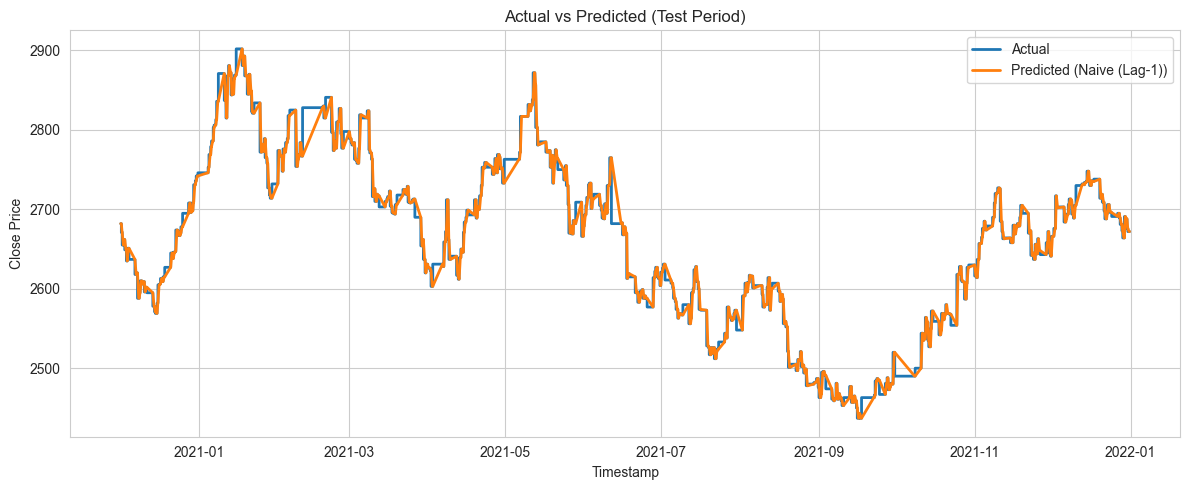

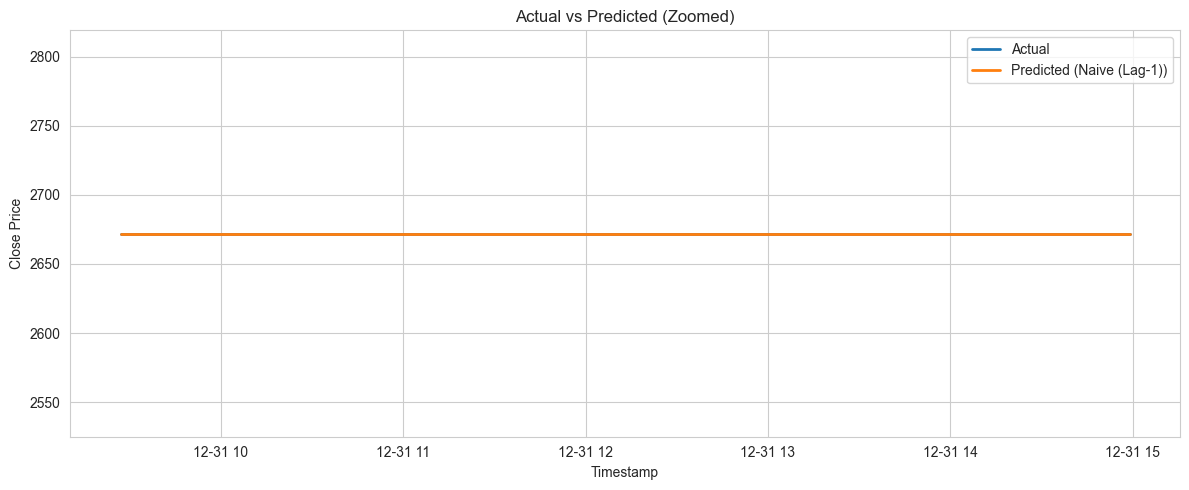

In [9]:
# Generate predictions for the best model
if best_model_name == "Naive (Lag-1)":
    best_ts = test_df["timestamp"].values
    best_true = y_test.values
    best_pred = test_df["close"].values
elif best_model_name == "Linear Regression":
    best_ts = test_df["timestamp"].values
    best_true = y_test.values
    best_pred = models["Linear Regression"].predict(X_test)
elif best_model_name in ["Random Forest", "XGBoost"]:
    best_ts = test_df["timestamp"].values
    best_true = y_test.values
    best_pred = models[best_model_name].predict(X_test)
elif best_model_name == "LSTM" and best_model_name in extra_predictions:
    best_ts, best_true, best_pred = extra_predictions["LSTM"]
else:
    raise ValueError(f"Unsupported best model: {best_model_name}")

# Plot full test period
plt.figure(figsize=(12, 5))
plt.plot(best_ts, best_true, label="Actual", linewidth=2)
plt.plot(best_ts, best_pred, label=f"Predicted ({best_model_name})", linewidth=2)
plt.title("Actual vs Predicted (Test Period)")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

# Zoomed plot: last 200 points
zoom_n = min(200, len(best_ts))
plt.figure(figsize=(12, 5))
plt.plot(best_ts[-zoom_n:], np.array(best_true)[-zoom_n:], label="Actual", linewidth=2)
plt.plot(best_ts[-zoom_n:], np.array(best_pred)[-zoom_n:], label=f"Predicted ({best_model_name})", linewidth=2)
plt.title("Actual vs Predicted (Zoomed)")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Model Saving
We save the best model to `model/forecast_model.pkl`.

In [10]:
from pathlib import Path

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "forecast_model.pkl"

# Save best model (baseline saved as metadata-only)
if best_model_name == "Naive (Lag-1)":
    model_artifact = {
        "model": "naive_lag1",
        "feature_columns": FEATURE_COLUMNS,
        "target": "next_close",
    }
elif best_model_name == "LSTM":
    # Save LSTM separately, store reference in the .pkl artifact
    lstm_path = MODEL_DIR / "lstm_model.keras"
    models["LSTM"].save(lstm_path)
    model_artifact = {
        "model": "lstm",
        "model_path": str(lstm_path),
        "feature_columns": FEATURE_COLUMNS,
        "target": "next_close",
    }
else:
    model_artifact = {
        "model": best_model,
        "feature_columns": FEATURE_COLUMNS,
        "target": "next_close",
    }

joblib.dump(model_artifact, MODEL_PATH)
print(f"Saved best model to {MODEL_PATH.resolve()}")

Saved best model to C:\Users\User\Desktop\Ziad\Perso\Projects\AI Financial Forecasting & Assistant\model\forecast_model.pkl


## 11. Key Insights
- **Best model**: use the comparison table to identify the lowest RMSE model.
- **Predictability**: financial time series are noisy; improvements over the naive baseline indicate learnable structure.
- **Limitations**: models ignore external factors (news, macro events), and may struggle in regime shifts.
- **Potential improvements**: incorporate exogenous variables, tune hyperparameters, add cross-validation for time series, and test longer horizons.